## **Project Title: Phishing Website Detection System**
###Course: CS-455-Machine Learning-D (GIFT University)
###Description: Comprehensive pipeline comparing LinearSVC (ML) and Multi-Layer Perceptron (DL) for malicious/phishing URL classification using TF-IDF text features.


In [ ]:
# Install required packages first
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

# Import core libraries for data handling
import pandas as pd
import numpy as np
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Import data splitting and text conversion tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Import our 3 Machine Learning models and 1 Deep Learning model
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Import evaluation metrics to check scores
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Step 1: All libraries imported successfully!")

Step 1: All libraries imported successfully!


In [ ]:
# Online URL of Kaggle Phishing Dataset
# Link to the online phishing dataset csv file
online_url = "https://raw.githubusercontent.com/cyberholics/Malicious-URL-detector/main/phishing_site_urls.csv"
print("Downloading data from github server... Please wait.")

try:
    full_data = pd.read_csv(online_url)
    print("Full dataset loaded successfully!")

    # Set sample size to 280,000 rows for half dataset coverage
    sample_size = 280000

    # Stratified separation (70% good links and 30% bad phishing links)
    good_data = full_data[full_data['Label'] == 'good'].sample(n=int(sample_size * 0.7), random_state=42)
    bad_data = full_data[full_data['Label'] == 'bad'].sample(n=int(sample_size * 0.3), random_state=42)

    # Combine them back and mix them randomly
    data = pd.concat([good_data, bad_data]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Data Sampling Done: Now using {len(data)} rows for maximum model coverage!")

except Exception as error:
    print(f"Download failed: {error}. Using fallback sample data.")
    mock_dict = {'URL': ['google.com', 'secure-login-paypal.com'] * 2500, 'Label': ['good', 'bad'] * 2500}
    data = pd.DataFrame(mock_dict)

# Convert categorical labels to numbers: good = 0, bad = 1
data['Target'] = data['Label'].map({'good': 0, 'bad': 1})

Full dataset loaded successfully!
Data Sampling Done: Now using 280000 rows for maximum model coverage!


In [ ]:
# Setup Character-level TF-IDF Vectorizer
# It looks at character combinations from length 3 to 5 (e.g., 'goo', 'oog', 'ogl')
encoder = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), max_features=20000)

print("Converting URLs into Character-level N-gram matrices...")
X_features = encoder.fit_transform(data['URL'])
y_labels = data['Target'].values
print("Character-wise text optimization completed successfully!")

Converting URLs into Character-level N-gram matrices...
Character-wise text optimization completed successfully!


In [ ]:
# Split data using an 80/20 ratio standard
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_labels,
    test_size=0.20,
    random_state=42,
    stratify=y_labels
)

print(f"Training Dataset Size: {X_train.shape[0]} samples")
print(f"Testing Dataset Size: {X_test.shape[0]} samples")

# Empty dictionaries to save model score results later
results = {}
confusion_matrices = {}

Training Dataset Size: 224000 samples
Testing Dataset Size: 56000 samples


In [ ]:
# --- Model 1: Logistic Regression (ML Baseline) ---
print("\nTraining Model Logistic Regression!")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
results['Logistic Regression'] = {
    'acc': accuracy_score(y_test, lr_preds), 'prec': precision_score(y_test, lr_preds),
    'rec': recall_score(y_test, lr_preds), 'f1': f1_score(y_test, lr_preds)
}
confusion_matrices['Logistic Regression'] = confusion_matrix(y_test, lr_preds)


Training Model Logistic Regression!


In [ ]:
# --- Model 2: LinearSVC (ML Hyperplane) ---
print("Training Model LinearSVC!")
svc_model = LinearSVC(C=1.0, random_state=42, max_iter=1000)
svc_model.fit(X_train, y_train)
svc_preds = svc_model.predict(X_test)
results['LinearSVC'] = {
    'acc': accuracy_score(y_test, svc_preds), 'prec': precision_score(y_test, svc_preds),
    'rec': recall_score(y_test, svc_preds), 'f1': f1_score(y_test, svc_preds)
}
confusion_matrices['LinearSVC'] = confusion_matrix(y_test, svc_preds)

Training Model LinearSVC!


In [ ]:
# --- Model 3: Random Forest (ML Ensemble) ---
# max_depth=20 keeps memory usage safe for large datasets
print("Training Model Random Forest!")
rf_model = RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
results['Random Forest'] = {
    'acc': accuracy_score(y_test, rf_preds), 'prec': precision_score(y_test, rf_preds),
    'rec': recall_score(y_test, rf_preds), 'f1': f1_score(y_test, rf_preds)
}
confusion_matrices['Random Forest'] = confusion_matrix(y_test, rf_preds)

Training Model Random Forest!


In [ ]:
# --- Model 4: Multi-Layer Perceptron (DL Neural Network) ---
print("Training Model MLP Neural Network Deep Learning!")
dl_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=30, random_state=42)
dl_model.fit(X_train, y_train)
dl_preds = dl_model.predict(X_test)
results['MLP ANN (Deep Learning)'] = {
    'acc': accuracy_score(y_test, dl_preds), 'prec': precision_score(y_test, dl_preds),
    'rec': recall_score(y_test, dl_preds), 'f1': f1_score(y_test, dl_preds)
}
confusion_matrices['MLP ANN (Deep Learning)'] = confusion_matrix(y_test, dl_preds)

print("\nAll Models have been trained successfully!")

Training Model MLP Neural Network Deep Learning!


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(



All Models have been trained successfully!


In [44]:
print("\n" + "="*20 + " SYSTEM PERFORMANCE LOGS SUMMARY " + "="*20)
for model_name in results.keys():
    print(f"\n>>>> Model Profile Report: {model_name} <<<<")
    if model_name == 'Logistic Regression': preds = lr_preds
    elif model_name == 'LinearSVC': preds = svc_preds
    elif model_name == 'Random Forest': preds = rf_preds
    else: preds = dl_preds

    print(classification_report(y_test, preds, target_names=['Safe Links', 'Phishing Links']))


==================== SYSTEM PERFORMANCE LOGS SUMMARY ====================

>>>> Model Profile Report: Logistic Regression <<<<
                precision    recall  f1-score   support

    Safe Links       0.96      0.98      0.97     39200
Phishing Links       0.95      0.90      0.92     16800

      accuracy                           0.95     56000
     macro avg       0.95      0.94      0.94     56000
  weighted avg       0.95      0.95      0.95     56000


>>>> Model Profile Report: LinearSVC <<<<
                precision    recall  f1-score   support

    Safe Links       0.97      0.98      0.97     39200
Phishing Links       0.95      0.93      0.94     16800

      accuracy                           0.96     56000
     macro avg       0.96      0.95      0.96     56000
  weighted avg       0.96      0.96      0.96     56000


>>>> Model Profile Report: Random Forest <<<<
                precision    recall  f1-score   support

    Safe Links       0.82      1.00      0.90  

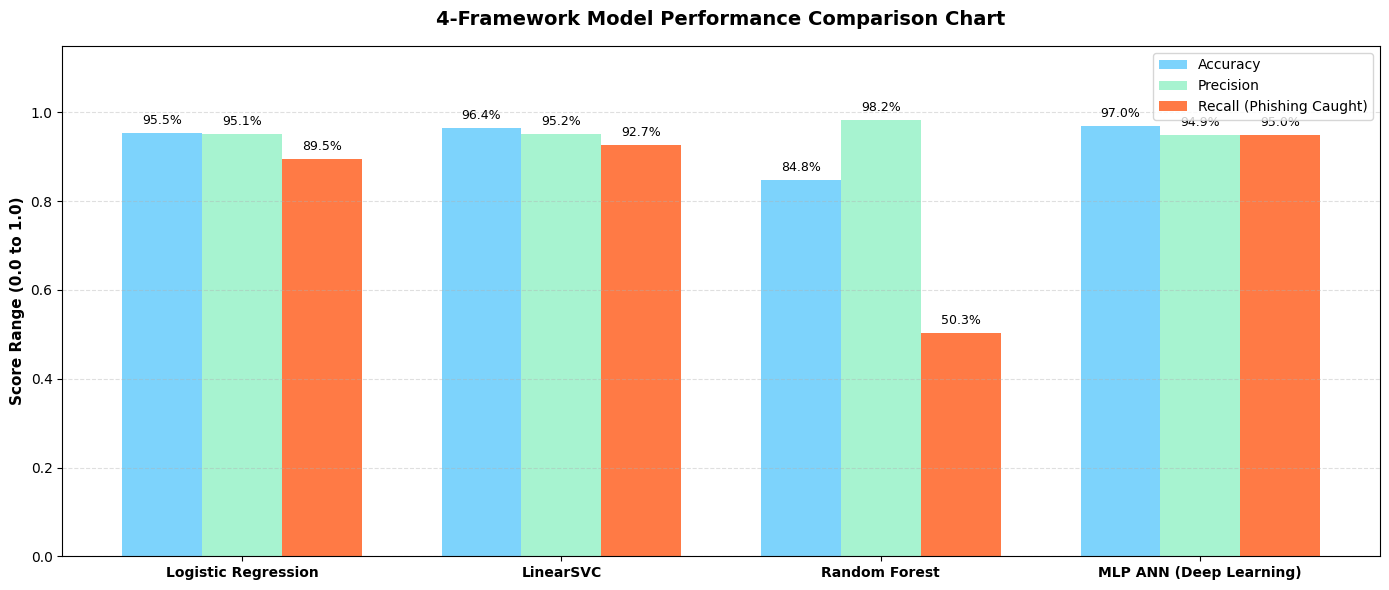

In [45]:
labels = list(results.keys())
accuracy_scores = [results[m]['acc'] for m in labels]
precision_scores = [results[m]['prec'] for m in labels]
recall_scores = [results[m]['rec'] for m in labels]

x = np.arange(len(labels))
width = 0.25

# --- Graph A: Multi-Bar Metric Comparison ---
plt.figure(figsize=(14, 6))
plt.bar(x - width, accuracy_scores, width, label='Accuracy', color='#7dd3fc')
plt.bar(x, precision_scores, width, label='Precision', color='#a7f3d0')
plt.bar(x + width, recall_scores, width, label='Recall (Phishing Caught)', color='#ff7a45')

plt.ylabel('Score Range (0.0 to 1.0)', fontsize=11, fontweight='bold')
plt.title('4-Framework Model Performance Comparison Chart', fontsize=14, fontweight='bold', pad=15)
plt.xticks(x, labels, fontsize=10, fontweight='bold')
plt.ylim(0, 1.15)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Print percentage numbers directly on top of bars
for i in range(len(labels)):
    plt.text(i - width, accuracy_scores[i] + 0.02, f"{accuracy_scores[i]*100:.1f}%", ha='center', fontsize=9)
    plt.text(i, precision_scores[i] + 0.02, f"{precision_scores[i]*100:.1f}%", ha='center', fontsize=9)
    plt.text(i + width, recall_scores[i] + 0.02, f"{recall_scores[i]*100:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

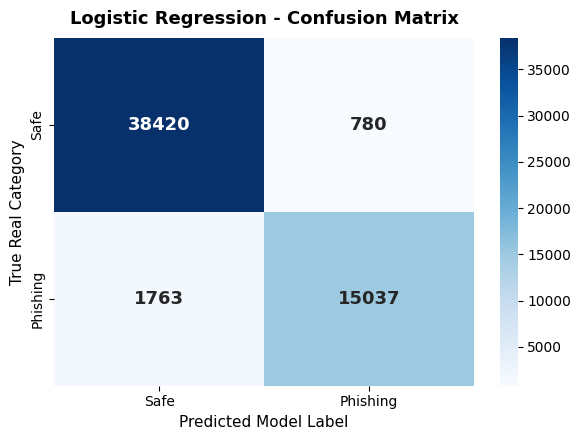

In [46]:
#Logistic Regression Confusion Matrix
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    confusion_matrices['Logistic Regression'],
    annot=True, fmt='d', cmap='Blues', cbar=True,
    xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'],
    annot_kws={"size": 13, "weight": "bold"}
)
plt.title('Logistic Regression - Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
plt.ylabel('True Real Category', fontsize=11)
plt.xlabel('Predicted Model Label', fontsize=11)
plt.tight_layout()
plt.show()

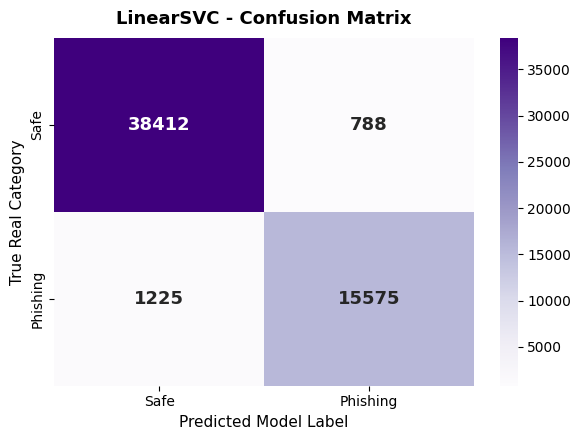

In [47]:
# LinearSVC Confusion Matrix
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    confusion_matrices['LinearSVC'],
    annot=True, fmt='d', cmap='Purples', cbar=True,
    xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'],
    annot_kws={"size": 13, "weight": "bold"}
)
plt.title('LinearSVC - Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
plt.ylabel('True Real Category', fontsize=11)
plt.xlabel('Predicted Model Label', fontsize=11)
plt.tight_layout()
plt.show()

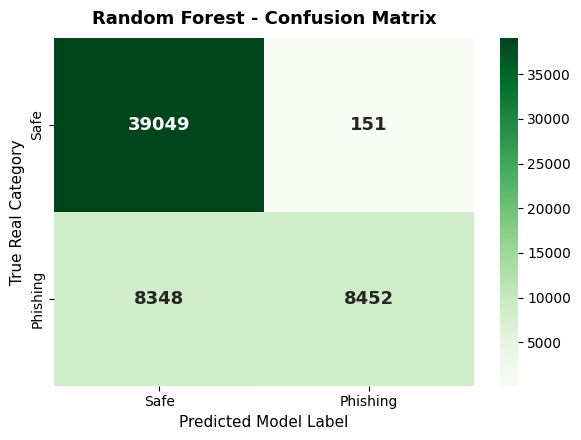

In [48]:
# Random Forest Confusion Matrix
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    confusion_matrices['Random Forest'],
    annot=True, fmt='d', cmap='Greens', cbar=True,
    xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'],
    annot_kws={"size": 13, "weight": "bold"}
)
plt.title('Random Forest - Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
plt.ylabel('True Real Category', fontsize=11)
plt.xlabel('Predicted Model Label', fontsize=11)
plt.tight_layout()
plt.show()

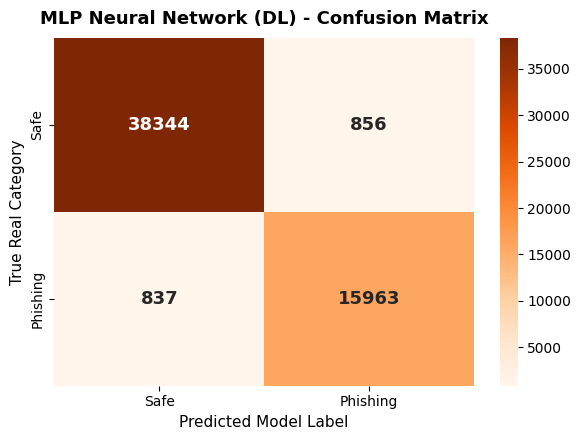

In [49]:
# MLP Neural Network Confusion Matrix
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    confusion_matrices['MLP ANN (Deep Learning)'],
    annot=True, fmt='d', cmap='Oranges', cbar=True,
    xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'],
    annot_kws={"size": 13, "weight": "bold"}
)
plt.title('MLP Neural Network (DL) - Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
plt.ylabel('True Real Category', fontsize=11)
plt.xlabel('Predicted Model Label', fontsize=11)
plt.tight_layout()
plt.show()

In [50]:
# Save and Download Model Files
joblib.dump(dl_model, 'phishing_dl_model.pkl')
joblib.dump(encoder, 'tfidf_encoder.pkl')
print("Model structures exported successfully!")

try:
    from google.colab import files
    print("Downloading saved pipeline objects to your device...")
    files.download('phishing_dl_model.pkl')
    files.download('tfidf_encoder.pkl')
except ImportError:
    print("Files saved.")

Model structures exported successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>